# Customer Churn Prediction using RFM Analysis

This project analyzes online retail customer behavior using RFM (Recency, Frequency, Monetary) analysis and machine learning models to predict customer churn.

## Imports

In [3]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

## Load Dataset

In [4]:


df = pd.read_excel(r"C:\Users\bhamr\Downloads\archive (1)\online_retail_II.xlsx")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Data Cleaning

In [5]:


df = df.dropna(subset=['Customer ID'])
df['Description'] = df['Description'].fillna('Unknown')

df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

## Feature Engineering

We create additional features to enrich the dataset and prepare it for RFM analysis and machine learning models.

In [6]:

df['TotalPrice'] = df['Quantity'] * df['Price']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Customer ID'] = df['Customer ID'].astype(int)

## RFM Analysis

We compute RFM (Recency, Frequency, Monetary) metrics for each customer:

- **Recency**: Days since last purchase  
- **Frequency**: Number of unique invoices  
- **Monetary**: Total spending  

We also define churn as customers who have not purchased in the last 90 days.

In [7]:

snapshot_date = df['InvoiceDate'].max()

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm['Churn'] = rfm['Recency'].apply(lambda x: 1 if x > 90 else 0)

rfm.head()

,Recency,Frequency,Monetary,Churn
Customer ID,,,,
12346,164,11,372.86,1
12347,2,2,1323.32,0
12348,73,1,222.16,0
12349,42,3,2671.14,0
12351,10,1,300.93,0


## Exploratory Data Analysis (EDA)

We analyze the distribution of RFM variables to understand customer behavior patterns.

### Recency Distribution

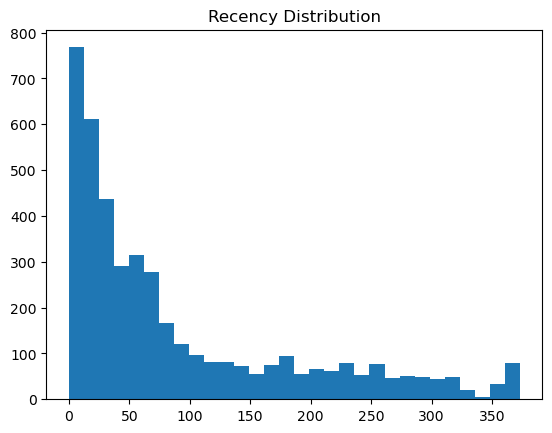

In [8]:

plt.hist(rfm['Recency'], bins=30)
plt.title('Recency Distribution')
plt.show()


### Insight

Most customers are recently active, indicating strong engagement within the customer base.

### Frequency Distribution

This shows how often customers make purchases.

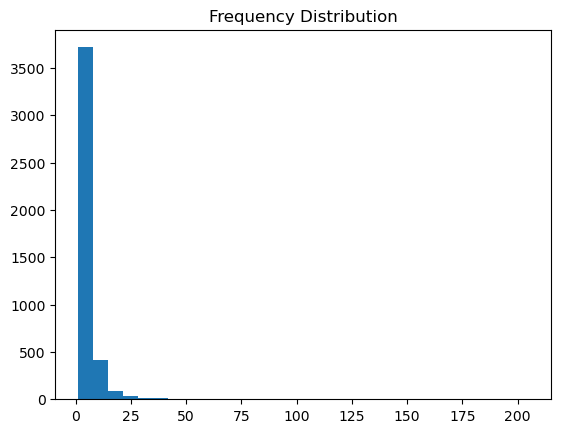

In [9]:

plt.hist(rfm['Frequency'], bins=30)
plt.title("Frequency Distribution")
plt.show()

### Monetary Distribution

This shows how much customers spend in total. It helps identify high-value vs low-value customers.

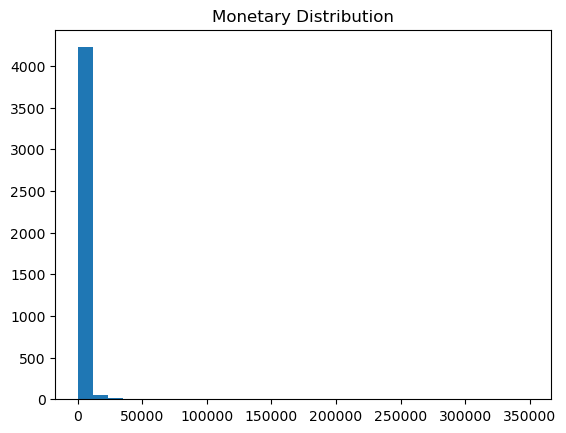

In [10]:

plt.hist(rfm['Monetary'], bins=30)
plt.title("Monetary Distribution")
plt.show()

### Insight

Revenue is highly skewed, meaning a small number of high-spending customers contribute disproportionately to total revenue.

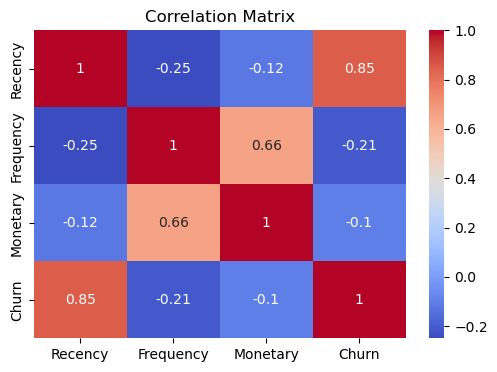

In [11]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(rfm.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Frequency vs Monetary

This plot shows the relationship between how often customers purchase and how much they spend in total.

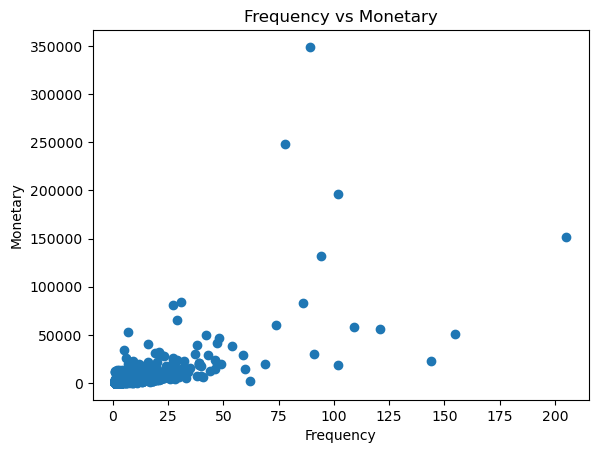

In [12]:

plt.scatter(rfm['Frequency'], rfm['Monetary'])
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Frequency vs Monetary")
plt.show()

### Recency vs Monetary

This plot shows the relationship between how recently a customer purchased and how much they have spent in total.

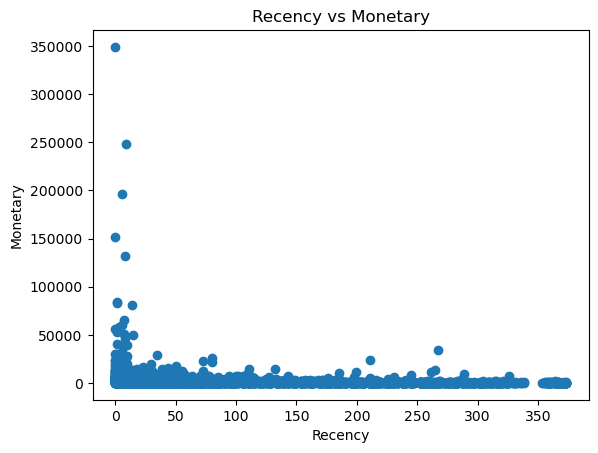

In [13]:

plt.scatter(rfm['Recency'], rfm['Monetary'])
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("Recency vs Monetary")
plt.show()

## Logistic Regression Model

We train a Logistic Regression model using RFM features (Recency, Frequency, Monetary) to predict customer churn.

The dataset is split into training and testing sets to evaluate model performance on unseen data.

In [14]:

X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       573
           1       1.00      1.00      1.00       290

    accuracy                           1.00       863
   macro avg       1.00      1.00      1.00       863
weighted avg       1.00      1.00      1.00       863



### Note on Model Performance

The Logistic Regression model achieved near-perfect accuracy because the churn label was directly derived from Recency, which is also included as an input feature.

This creates **target leakage**, leading to artificially inflated performance metrics.

## Time-Based Churn Modeling (Improved Approach)

We simulate a real-world scenario by splitting data based on time and defining churn using future customer activity.

In [15]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

cutoff = df['InvoiceDate'].quantile(0.8)

train = df[df['InvoiceDate'] <= cutoff]
test = df[df['InvoiceDate'] > cutoff]

snapshot = train['InvoiceDate'].max()

rfm_train = train.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})

rfm_train.columns = ['Recency', 'Frequency', 'Monetary']

active_test_customers = test['Customer ID'].unique()

rfm_train['Churn'] = ~rfm_train.index.isin(active_test_customers)
rfm_train['Churn'] = rfm_train['Churn'].astype(int)

### Feature Selection Note

Recency was excluded from the final Random Forest model because churn labels were derived from future customer activity, and Recency could indirectly encode temporal information related to the target.

## Random Forest Model (No Leakage Features)

We train a Random Forest model using only Frequency and Monetary features.

In [16]:


X = rfm_train[['Frequency', 'Monetary']]
y = rfm_train['Churn']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

pred = rf.predict(X_val)

print(classification_report(y_val, pred))


              precision    recall  f1-score   support

           0       0.55      0.53      0.54       321
           1       0.68      0.70      0.69       459

    accuracy                           0.63       780
   macro avg       0.62      0.62      0.62       780
weighted avg       0.63      0.63      0.63       780



In [23]:
# ROC-AUC Score
from sklearn.metrics import roc_auc_score

prob = rf.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y_val, prob)

print(f"ROC-AUC Score: {roc_auc:.3f}")

ROC-AUC Score: 0.671


The Random Forest model achieved a ROC-AUC score of 0.671, indicating fair ability to distinguish between customers who churned and those who remained active.

In [17]:
import joblib

joblib.dump(rf, "rf_model.pkl")

print("Model saved successfully")

Model saved successfully


In [18]:
import os
print(os.getcwd())

C:\Users\bhamr


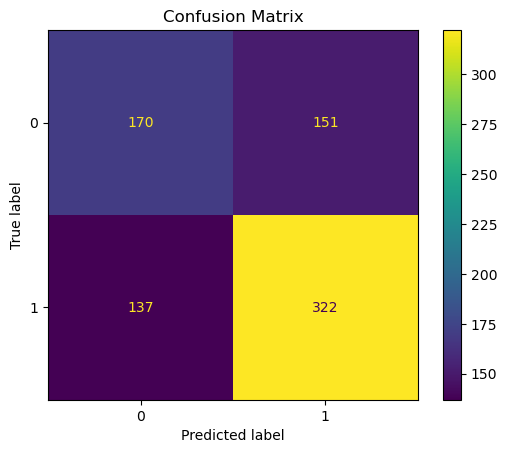

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_val, pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix")
plt.show()

## Feature Importance

We analyze feature importance from the Random Forest model to understand which variables contribute most to predicting customer churn.

In [20]:

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feat_imp

,Feature,Importance
1,Monetary,0.873699
0,Frequency,0.126301


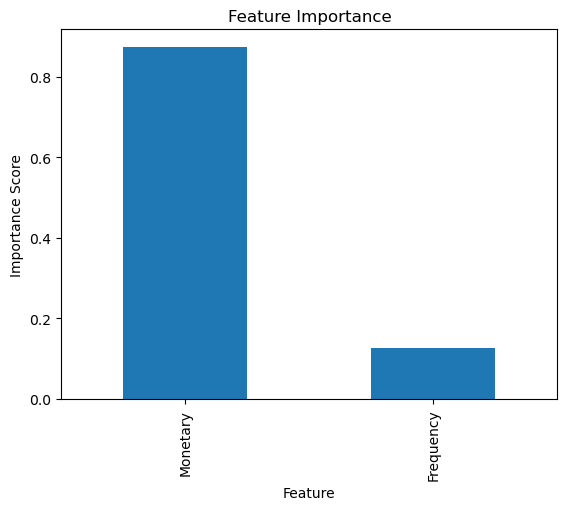

In [21]:
feat_imp.plot(
    x='Feature',
    y='Importance',
    kind='bar',
    legend=False
)

plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.show()

## Conclusion

- **Monetary value** was the strongest predictor of customer churn, indicating that high-value customers are the most critical segment to retain.

- Customers with **low purchase frequency** showed a higher likelihood of churn, highlighting the importance of engagement and repeat purchases.

- The **Random Forest model** provided a more realistic evaluation compared to Logistic Regression, which was affected by target leakage.

- Overall, **RFM analysis proved to be an effective framework** for customer segmentation and churn prediction in retail data.